In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:
data = load_breast_cancer()
X,y = data.data,data.target

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [4]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print("Original shape:", X_scaled.shape, "-> reduced:", X_pca.shape)

Original shape: (569, 30) -> reduced: (569, 2)


In [5]:
evr = pca.explained_variance_ratio_
print("Variance explained by PC1, PC2:", np.round(evr, 3))
print("Total kept with just 2 of 30 features:", round(evr.sum(), 3))

Variance explained by PC1, PC2: [0.443 0.19 ]
Total kept with just 2 of 30 features: 0.632


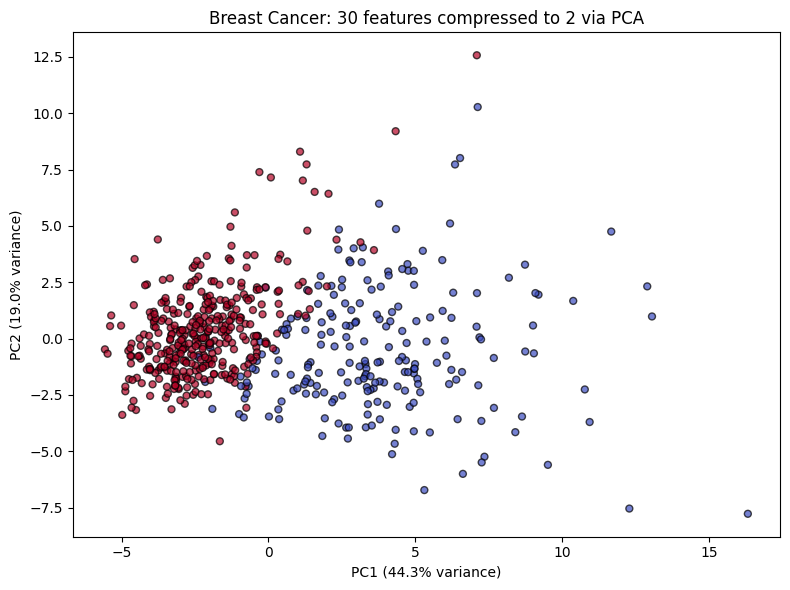

In [6]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='coolwarm', s=25, alpha=0.7, edgecolor='k')
plt.xlabel(f'PC1 ({evr[0]:.1%} variance)'); plt.ylabel(f'PC2 ({evr[1]:.1%} variance)')
plt.title('Breast Cancer: 30 features compressed to 2 via PCA')
plt.tight_layout(); plt.savefig('pca.png', dpi=110); plt.show()

**Logistic reg + PCA**

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42, stratify=data.target)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_s)
X_test_pca = pca.transform(X_test_s)
print("Original shape:", X_train_s.shape, "-> reduced:", X_train_pca.shape)


Original shape: (455, 30) -> reduced: (455, 2)


In [8]:
clf = LogisticRegression(max_iter=5000,random_state=42)
clf.fit(X_train_pca,y_train)

LogisticRegression(max_iter=5000, random_state=42)

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
y_pred = clf.predict(X_test_pca)
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1       :", round(f1_score(y_test, y_pred), 4))

Accuracy : 0.9474
Precision: 0.9714
Recall   : 0.9444
F1       : 0.9577
